# Filamentary Structure Generator

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Callable
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 1 · User Parameters

In [27]:
N_FILAMENTS     = 1000
RANDOM_SEED     = 42

CANVAS_SIZE     = (1000, 1000)

LENGTH_MIN      = 15
LENGTH_MAX      = 800

WIDTH_MIN       = 5.0
WIDTH_MAX       = 125.0
WIDTH_LENGTH_ALPHA   = 0.5
WIDTH_SCATTER_SIGMA  = 0.25

CURVATURE_MIN   = 0.0
CURVATURE_MAX   = 0.5

# Intensity sampling via Gamma(alpha, beta).
# Two values drawn independently, clipped to [INTENSITY_MIN, INTENSITY_MAX],
# sorted so i_lo <= i_hi.  Profile oscillates between these two values.
#
# mean = alpha * beta.  Default alpha=0.5, beta=3.0 -> mean=1.5, strongly
# skewed toward low values (mode=0), long tail up to INTENSITY_MAX.
INTENSITY_MIN         = 0.05
INTENSITY_MAX         = 5.0
INTENSITY_GAMMA_ALPHA = 0.5   # <1 = strong low-intensity bias
INTENSITY_GAMMA_BETA  = 3.0   # scale; mean = alpha * beta = 1.5

INTENSITY_PROFILES = ['constant', 'linear', 'sin', 'sin2', 'gaussian']

print('Parameters set.')

Parameters set.


## 2 · Core Engine

In [28]:
def profile_constant(t, lo, hi):
    return np.full_like(t, hi)

def profile_linear(t, lo, hi):
    ramp = lo + (hi - lo) * t
    return ramp if np.random.rand() > 0.5 else ramp[::-1].copy()

def profile_sin(t, lo, hi):
    return lo + (hi - lo) * 0.5 * (1 + np.sin(2 * np.pi * t))

def profile_sin2(t, lo, hi):
    return lo + (hi - lo) * 0.5 * (1 + np.sin(4 * np.pi * t))

def profile_gaussian(t, lo, hi):
    return lo + (hi - lo) * np.exp(-0.5 * ((t - 0.5) / 0.2) ** 2)

PROFILE_MAP: dict[str, Callable] = {
    'constant': profile_constant,
    'linear':   profile_linear,
    'sin':      profile_sin,
    'sin2':     profile_sin2,
    'gaussian': profile_gaussian,
}


def sample_intensity_pair(rng=None):
    """
    Draw two independent Gamma(alpha, beta) samples, clip to
    [INTENSITY_MIN, INTENSITY_MAX], return sorted (lo, hi).
    """
    draw = rng.gamma if rng is not None else np.random.gamma
    a, b = INTENSITY_GAMMA_ALPHA, INTENSITY_GAMMA_BETA
    v1 = float(np.clip(draw(a, b), INTENSITY_MIN, INTENSITY_MAX))
    v2 = float(np.clip(draw(a, b), INTENSITY_MIN, INTENSITY_MAX))
    return (v1, v2) if v1 <= v2 else (v2, v1)


def random_walk_path(start, initial_angle, n_steps, curvature, step_size=1.0):
    path = np.empty((n_steps + 1, 2))
    path[0] = start
    angle = initial_angle
    for i in range(n_steps):
        angle += np.random.normal(0, curvature)
        path[i + 1] = path[i] + step_size * np.array([np.sin(angle), np.cos(angle)])
    return path


def render_filament(image, path, width, intensity_values, support=4.0):
    """
    Stamp a Moffat (beta=3) kernel along each path step, accumulating onto
    image, then rescale so peak pixel == max(intensity_values).

    Rescaling after accumulation is essential: adjacent steps are 1 px apart
    but kernels span many pixels, so overlap causes raw pixel values to far
    exceed i_hi.  The rescale preserves profile shape (all pixel ratios kept)
    while guaranteeing peak <= i_hi.
    """
    rows, cols = image.shape
    hw = int(np.ceil(support * width))
    gy, gx = np.mgrid[-hw:hw + 1, -hw:hw + 1].astype(float)
    r2     = (gx ** 2 + gy ** 2) / width ** 2
    kernel = (1.0 + r2) ** (-3.0)
    kernel /= kernel.max()

    for (r, c), amp in zip(path, intensity_values):
        ri, ci = int(round(r)), int(round(c))
        r0 = max(0, ri - hw);  r1 = min(rows, ri + hw + 1)
        c0 = max(0, ci - hw);  c1 = min(cols, ci + hw + 1)
        if r0 >= r1 or c0 >= c1:
            continue
        kr0 = r0 - (ri - hw);  kr1 = kr0 + (r1 - r0)
        kc0 = c0 - (ci - hw);  kc1 = kc0 + (c1 - c0)
        image[r0:r1, c0:c1] += amp * kernel[kr0:kr1, kc0:kc1]

    img_max = image.max()
    if img_max > 0:
        image *= float(intensity_values.max()) / img_max


def measure_tortuosity(path):
    segments   = np.linalg.norm(np.diff(path, axis=0), axis=1)
    path_len   = float(np.sum(segments))
    end_to_end = float(np.linalg.norm(path[-1] - path[0]))
    if end_to_end < 1e-12:
        return float('inf')
    return path_len / end_to_end


def sample_length_width(rng=None):
    if rng is not None:
        log_len = rng.uniform(np.log(LENGTH_MIN), np.log(LENGTH_MAX))
        scatter = rng.normal(0.0, WIDTH_SCATTER_SIGMA)
    else:
        log_len = np.random.uniform(np.log(LENGTH_MIN), np.log(LENGTH_MAX))
        scatter = np.random.normal(0.0, WIDTH_SCATTER_SIGMA)
    length      = max(1, int(np.exp(log_len)))
    frac        = (length - LENGTH_MIN) / (LENGTH_MAX - LENGTH_MIN)
    width_trend = WIDTH_MIN + (WIDTH_MAX - WIDTH_MIN) * frac ** WIDTH_LENGTH_ALPHA
    width       = float(np.clip(width_trend * np.exp(scatter), WIDTH_MIN, WIDTH_MAX))
    return length, width


def generate_one_filament():
    length, width = sample_length_width()
    curvature    = np.random.uniform(CURVATURE_MIN, CURVATURE_MAX)
    i_lo, i_hi   = sample_intensity_pair()
    profile_name = np.random.choice(INTENSITY_PROFILES)

    rows, cols = CANVAS_SIZE
    start = (rows / 2, cols / 2)
    angle = np.random.uniform(0, 2 * np.pi)

    path = random_walk_path(start, angle, length, curvature)
    t    = np.linspace(0.0, 1.0, len(path))
    intensity_values = PROFILE_MAP[profile_name](t, i_lo, i_hi)

    image = np.zeros(CANVAS_SIZE, dtype=float)
    render_filament(image, path, width, intensity_values)

    meta = dict(
        length     = length,
        width      = round(width, 2),
        curv_param = round(curvature, 3),
        tortuosity = round(measure_tortuosity(path), 3),
        i_lo       = round(i_lo, 4),
        i_hi       = round(i_hi, 4),
        profile    = profile_name,
    )
    return image, path, meta


print('Engine ready.')

Engine ready.


## 3 · Display N Filaments

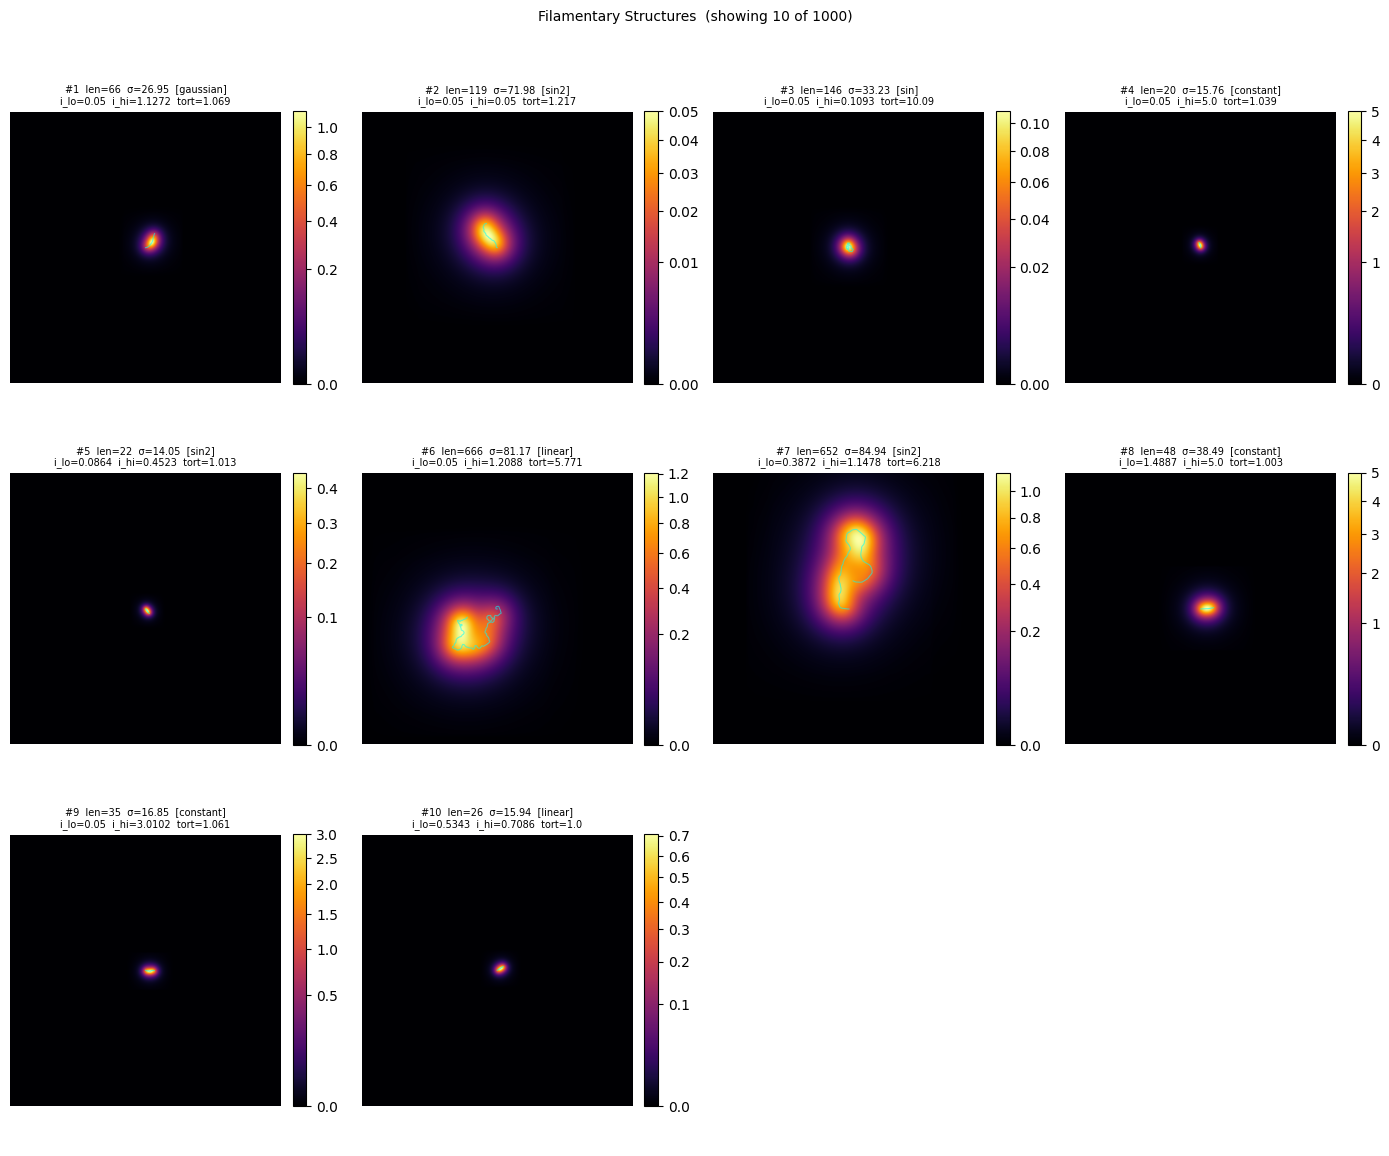

Displayed 10 of 1000 filaments.


In [29]:
if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

for p in INTENSITY_PROFILES:
    assert p in PROFILE_MAP, f"Unknown profile '{p}'"

to_show = 10
all_filaments     = [generate_one_filament() for _ in range(N_FILAMENTS)]
display_filaments = all_filaments[:to_show]

ncols = int(np.ceil(np.sqrt(to_show)))
nrows = int(np.ceil(to_show / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.8 * nrows), squeeze=False)
fig.suptitle(f'Filamentary Structures  (showing {to_show} of {N_FILAMENTS})', fontsize=10, y=1.01)

rows_c, cols_c = CANVAS_SIZE
for idx in range(nrows * ncols):
    ax = axes[idx // ncols][idx % ncols]
    if idx < to_show:
        image, path, meta = display_filaments[idx]
        im = ax.imshow(image, origin='upper', cmap='inferno',
                       norm=mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(image.max(), 1e-6)))
        in_bounds = ((path[:, 0] >= 0) & (path[:, 0] < rows_c) &
                     (path[:, 1] >= 0) & (path[:, 1] < cols_c))
        ax.plot(path[in_bounds, 1], path[in_bounds, 0], color='cyan', lw=0.8, alpha=0.55)
        ax.set_title(
            f"#{idx+1}  len={meta['length']}  σ={meta['width']}  [{meta['profile']}]\n"
            f"i_lo={meta['i_lo']}  i_hi={meta['i_hi']}  tort={meta['tortuosity']}",
            fontsize=7,
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Displayed {to_show} of {N_FILAMENTS} filaments.')

## 4 · Intensity Distribution Validation

Gamma(α=0.5, β=3.0)  theoretical mean = 1.500
i_lo  p10=0.05  p50=0.197  p90=1.44  mean=0.518
i_hi  p10=0.224  p50=1.54  p90=5  mean=2.03
range p10=0.0881  p50=1.02  p90=3.93


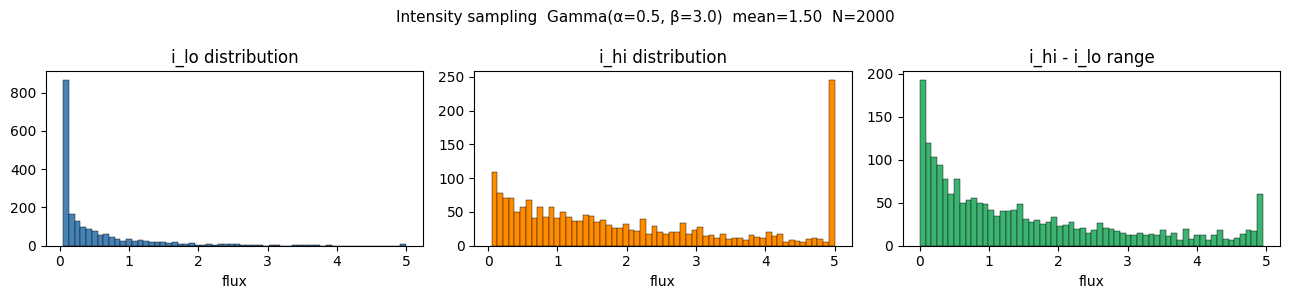

In [30]:
if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

N_SAMPLE = 2000
ilos, ihis = zip(*[sample_intensity_pair() for _ in range(N_SAMPLE)])
ilos, ihis = np.array(ilos), np.array(ihis)
ranges     = ihis - ilos

print(f"Gamma(α={INTENSITY_GAMMA_ALPHA}, β={INTENSITY_GAMMA_BETA})  "
      f"theoretical mean = {INTENSITY_GAMMA_ALPHA * INTENSITY_GAMMA_BETA:.3f}")
print(f"i_lo  p10={np.percentile(ilos,10):.3g}  p50={np.percentile(ilos,50):.3g}  "
      f"p90={np.percentile(ilos,90):.3g}  mean={ilos.mean():.3g}")
print(f"i_hi  p10={np.percentile(ihis,10):.3g}  p50={np.percentile(ihis,50):.3g}  "
      f"p90={np.percentile(ihis,90):.3g}  mean={ihis.mean():.3g}")
print(f"range p10={np.percentile(ranges,10):.3g}  p50={np.percentile(ranges,50):.3g}  "
      f"p90={np.percentile(ranges,90):.3g}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].hist(ilos,   bins=60, color='steelblue',      edgecolor='k', lw=0.3)
axes[0].set_title('i_lo distribution'); axes[0].set_xlabel('flux')
axes[1].hist(ihis,   bins=60, color='darkorange',     edgecolor='k', lw=0.3)
axes[1].set_title('i_hi distribution'); axes[1].set_xlabel('flux')
axes[2].hist(ranges, bins=60, color='mediumseagreen', edgecolor='k', lw=0.3)
axes[2].set_title('i_hi - i_lo range'); axes[2].set_xlabel('flux')
plt.suptitle(
    f'Intensity sampling  Gamma(α={INTENSITY_GAMMA_ALPHA}, β={INTENSITY_GAMMA_BETA})  '
    f'mean={INTENSITY_GAMMA_ALPHA*INTENSITY_GAMMA_BETA:.2f}  N={N_SAMPLE}',
    fontsize=11)
plt.tight_layout()
plt.show()

## 5 · Intensity Profile Reference

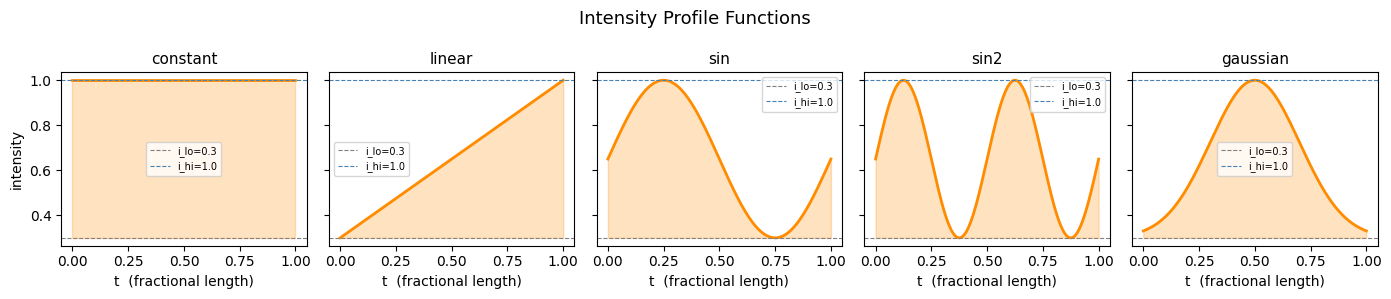

In [31]:
t = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, len(PROFILE_MAP), figsize=(14, 3), sharey=True)
lo, hi = 0.3, 1.0

for ax, (name, fn) in zip(axes, PROFILE_MAP.items()):
    np.random.seed(0)
    vals = fn(t, lo, hi)
    ax.fill_between(t, lo, vals, alpha=0.25, color='darkorange')
    ax.plot(t, vals, lw=2, color='darkorange')
    ax.axhline(lo, ls='--', lw=0.8, color='grey',      label=f'i_lo={lo}')
    ax.axhline(hi, ls='--', lw=0.8, color='steelblue', label=f'i_hi={hi}')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('t  (fractional length)')
    if ax is axes[0]: ax.set_ylabel('intensity')
    ax.legend(fontsize=7)

plt.suptitle('Intensity Profile Functions', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Inject into FITS Images

In [32]:
INPUT_FOLDER       = r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\OriginalImages"
OUTPUT_FOLDER      = r"C:\Users\jhoffm72\Documents\FilPHANGS\Validation_Data\OriginalImages"
N_INJECT           = 75
N_POOL             = 1000
RANDOM_SEED_INJECT = 7
CATALOG_CSV        = 'filament_catalog.csv'

import os, uuid
import cv2
import pandas as pd
import matplotlib.patches as mpatches
from astropy.io import fits

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

fits_files = sorted([f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.fits', '.fit'))])
if not fits_files:
    raise FileNotFoundError(f"No FITS files found in {INPUT_FOLDER!r}")
print(f"Found {len(fits_files)} FITS file(s): {fits_files}")

rng_pool = np.random.default_rng(RANDOM_SEED_INJECT)
pool = []
for _ in range(N_POOL):
    length, width = sample_length_width(rng_pool)
    i_lo, i_hi    = sample_intensity_pair(rng_pool)
    pool.append(dict(
        length  = length,
        width   = width,
        curv    = float(rng_pool.uniform(CURVATURE_MIN, CURVATURE_MAX)),
        i_lo    = i_lo,
        i_hi    = i_hi,
        profile = rng_pool.choice(INTENSITY_PROFILES),
        angle   = float(rng_pool.uniform(0, 2 * np.pi)),
        seed    = int(rng_pool.integers(0, 2**31)),
    ))

pool_ihis = [p['i_hi'] for p in pool]
print(f"Pool i_hi  p10={np.percentile(pool_ihis,10):.3g}  "
      f"p50={np.percentile(pool_ihis,50):.3g}  "
      f"p90={np.percentile(pool_ihis,90):.3g}  "
      f"max={max(pool_ihis):.3g}")


def build_mask(data):
    threshold = 1e-20
    kernel    = np.ones((3, 3), np.uint8)
    mc  = data.astype(np.float32).copy()
    mc[mc > threshold] = 255
    mc  = mc.astype(np.uint8)
    dil = cv2.dilate(mc, kernel, iterations=5)
    tmp = data.astype(np.float32).copy()
    tmp[dil < threshold] = np.nan
    mask = np.isnan(tmp)
    bm   = np.zeros_like(tmp, dtype=np.uint8)
    bm[mask] = 255
    bm2  = cv2.dilate(bm, kernel, iterations=1)
    tmp2 = data.astype(np.float32).copy()
    tmp2[bm2 == 255] = np.nan
    return np.isnan(tmp2)


def get_footprint(path, width, img_rows, img_cols):
    hw      = int(np.ceil(4 * width))
    pr      = np.round(path[:, 0]).astype(int)
    pc      = np.round(path[:, 1]).astype(int)
    offsets = np.arange(-hw, hw + 1)
    dr, dc  = np.meshgrid(offsets, offsets, indexing='ij')
    dr = dr.ravel(); dc = dc.ravel()
    all_r = (pr[:, None] + dr[None, :]).ravel()
    all_c = (pc[:, None] + dc[None, :]).ravel()
    valid = (all_r >= 0) & (all_r < img_rows) & (all_c >= 0) & (all_c < img_cols)
    fp    = np.zeros((img_rows, img_cols), dtype=bool)
    fp[all_r[valid], all_c[valid]] = True
    return fp


def inject_into_image(data, pool, n_inject, rng, image_id):
    img_rows, img_cols = data.shape
    mask = build_mask(data)
    valid_rows, valid_cols = np.where(~mask)
    print(f"  [{image_id}] shape={data.shape}  valid={len(valid_rows):,} px")

    filament_canvas = np.zeros((img_rows, img_cols), dtype=np.float64)
    occupied        = np.zeros((img_rows, img_cols), dtype=bool)
    catalog_rows    = []
    pool_order      = rng.permutation(N_POOL).tolist()
    placed          = 0
    pool_idx        = 0

    while placed < n_inject and pool_idx < N_POOL:
        p = pool[pool_order[pool_idx]]
        pool_idx += 1

        if len(valid_rows) == 0:
            break
        si    = int(rng.integers(0, len(valid_rows)))
        start = (float(valid_rows[si]), float(valid_cols[si]))

        np.random.seed(p['seed'])
        path = random_walk_path(start, p['angle'], p['length'], p['curv'])

        pr = np.round(path[:, 0]).astype(int)
        pc = np.round(path[:, 1]).astype(int)
        in_bounds = (pr >= 0) & (pr < img_rows) & (pc >= 0) & (pc < img_cols)
        if not in_bounds.all():
            continue
        if mask[pr, pc].any():
            continue

        fp = get_footprint(path, p['width'], img_rows, img_cols)
        if occupied[fp].any():
            continue

        occupied |= fp
        t                = np.linspace(0.0, 1.0, len(path))
        intensity_values = PROFILE_MAP[p['profile']](t, p['i_lo'], p['i_hi'])

        fil_tmp = np.zeros((img_rows, img_cols), dtype=np.float64)
        render_filament(fil_tmp, path, p['width'], intensity_values)

        # Hard safety check — must never fire given correct render_filament.
        peak = fil_tmp.max()
        if peak > p['i_hi'] * 1.001:
            raise RuntimeError(f"Intensity overflow: peak={peak:.4g} > i_hi={p['i_hi']:.4g}")

        filament_canvas += fil_tmp
        placed += 1
        catalog_rows.append({
            'image_id':       image_id,
            'label':          placed,
            'length':         p['length'],
            'width':          round(p['width'], 2),
            'tortuosity':     round(measure_tortuosity(path), 3),
            'profile':        p['profile'],
            'i_lo':           round(p['i_lo'], 4),
            'i_hi':           round(p['i_hi'], 4),
            'mean_intensity': round(float(intensity_values.mean()), 4),
            'injected_flux':  round(float(np.nansum(fil_tmp[fp])), 4),
            'path_r':         ';'.join(f'{v:.2f}' for v in path[:, 0].tolist()),
            'path_c':         ';'.join(f'{v:.2f}' for v in path[:, 1].tolist()),
        })

    print(f"  [{image_id}] placed {placed} / {n_inject} (tried {pool_idx} pool entries).")
    return filament_canvas, catalog_rows


def annotate_filaments(ax, catalog_rows, pad=6, box_color='lime', fontsize=5):
    for row in catalog_rows:
        rs = np.array([float(v) for v in row['path_r'].split(';')])
        cs = np.array([float(v) for v in row['path_c'].split(';')])
        r_min, r_max = rs.min() - pad, rs.max() + pad
        c_min, c_max = cs.min() - pad, cs.max() + pad
        rect = mpatches.Rectangle(
            (c_min, r_min), c_max - c_min, r_max - r_min,
            linewidth=0.6, edgecolor=box_color, facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(c_min + 1, r_min + 1, str(row['label']),
                color=box_color, fontsize=fontsize, va='top', ha='left', fontweight='bold',
                bbox=dict(boxstyle='square,pad=0.1', fc='black', ec='none', alpha=0.55))


rng_main    = np.random.default_rng(RANDOM_SEED_INJECT + 1)
all_catalog = []

for fits_fname in fits_files:
    fits_path = os.path.join(INPUT_FOLDER, fits_fname)
    base_name = os.path.splitext(fits_fname)[0]
    image_id  = str(uuid.uuid4())[:8].upper()
    out_fname = f"{base_name}_modified_{image_id}.fits"
    out_path  = os.path.join(OUTPUT_FOLDER, out_fname)
    print(f"\nProcessing: {fits_fname}  ->  {out_fname}")

    hdul    = fits.open(fits_path)
    hdu_idx = next((i for i, h in enumerate(hdul) if h.data is not None and h.data.ndim >= 2), None)
    if hdu_idx is None:
        print(f"  WARNING: no 2-D data found in {fits_fname}, skipping.")
        hdul.close()
        continue

    data = np.squeeze(hdul[hdu_idx].data).astype(np.float64)
    hdul.close()

    valid_pix = data[~np.isnan(data)]
    print(f"  Image flux  p1={np.nanpercentile(valid_pix,1):.4g}  "
          f"median={np.nanpercentile(valid_pix,50):.4g}  "
          f"p99={np.nanpercentile(valid_pix,99):.4g}")

    filament_canvas, catalog_rows = inject_into_image(data, pool, N_INJECT, rng_main, image_id)
    blended_data = data + filament_canvas

    out_hdul   = fits.open(fits_path)
    orig_dtype = out_hdul[hdu_idx].data.dtype
    out_hdul[hdu_idx].data = blended_data.reshape(out_hdul[hdu_idx].data.shape).astype(orig_dtype)
    out_hdul[hdu_idx].header['IMG_ID'] = (image_id,          'Synthetic injection run ID')
    out_hdul[hdu_idx].header['N_FILS'] = (len(catalog_rows), 'Number of injected filaments')
    out_hdul[hdu_idx].header['ORIG']   = (fits_fname,        'Original filename')
    out_hdul.writeto(out_path, overwrite=True)
    out_hdul.close()
    print(f"  Saved -> {out_path}")

    all_catalog.extend(catalog_rows)

    lo_p, hi_p   = np.nanpercentile(data[~np.isnan(data)], [1, 99])
    img_range    = hi_p - lo_p + 1e-30
    display_real = np.clip((np.nan_to_num(data,         nan=0.0) - lo_p) / img_range, 0, 1)
    blended_disp = np.clip((np.nan_to_num(blended_data, nan=0.0) - lo_p) / img_range, 0, None)
    fil_max      = filament_canvas.max()

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(f'{fits_fname}  [ID: {image_id}]  ({len(catalog_rows)} filaments)', fontsize=10)
    axes[0].imshow(display_real,    origin='upper', cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Real image'); axes[0].axis('off')
    axes[1].imshow(filament_canvas, origin='upper', cmap='inferno',
                   norm=mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(fil_max, 1e-6)))
    annotate_filaments(axes[1], catalog_rows, pad=8, box_color='lime', fontsize=5)
    axes[1].set_title(f'Filaments only  (N={len(catalog_rows)})'); axes[1].axis('off')
    axes[2].imshow(blended_disp,    origin='upper', cmap='inferno',
                   norm=mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(blended_disp.max(), 1e-6)))
    annotate_filaments(axes[2], catalog_rows, pad=8, box_color='cyan', fontsize=5)
    axes[2].set_title('Blended'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

catalog_path = os.path.join(r"C:\Users\jhoffm72\Documents\FilPHANGS\Validation_Data", CATALOG_CSV)
catalog_df   = pd.DataFrame(all_catalog)
catalog_df.to_csv(catalog_path, index=False)
print(f"\nCatalog saved -> {catalog_path}  ({len(catalog_df)} rows)")
print(catalog_df[['image_id','label','length','width','profile',
                   'i_lo','i_hi','mean_intensity','tortuosity','injected_flux']].to_string(index=False))

Found 20 FITS file(s): ['IC5146_PSW_Herschel_Emission.fits', 'ngc0628_F2100W_JWST_Emission.fits', 'ngc0628_F770W_JWST_Emission_starsub.fits', 'ngc1087_F770W_JWST_Emission_starsub.fits', 'ngc1300_F770W_JWST_Emission_starsub.fits', 'ngc1365_F770W_JWST_Emission_starsub.fits', 'ngc1385_F770W_JWST_Emission_starsub.fits', 'ngc1433_F770W_JWST_Emission_starsub.fits', 'ngc1512_F770W_JWST_Emission_starsub.fits', 'ngc1566_F770W_JWST_Emission_starsub.fits', 'ngc2090_F555W_HST_Extinction.fits', 'ngc2835_F770W_JWST_Emission_starsub.fits', 'ngc3351_F770W_JWST_Emission_starsub.fits', 'ngc3627_F770W_JWST_Emission_starsub.fits', 'ngc4254_F770W_JWST_Emission_starsub.fits', 'ngc4303_F770W_JWST_Emission_starsub.fits', 'ngc4321_F770W_JWST_Emission_starsub.fits', 'ngc4535_F770W_JWST_Emission_starsub.fits', 'ngc5068_F770W_JWST_Emission_starsub.fits', 'ngc7496_F770W_JWST_Emission_starsub.fits']
Pool i_hi  p10=0.239  p50=1.58  p90=5  max=5

Processing: IC5146_PSW_Herschel_Emission.fits  ->  IC5146_PSW_Herschel_

KeyboardInterrupt: 